### HuyIGW04 - Softmax Regression - PyTorch - M05W02

In [70]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [71]:
data = np.genfromtxt('iris_2D_3c.csv', delimiter=',', skip_header=True)
X = torch.from_numpy(data[:, :-1]).float().to('cuda')
# 1-D vector
y = torch.from_numpy(data[:, -1]).long().to('cuda')
print(X.shape, y.shape)

torch.Size([9, 2]) torch.Size([9])


In [72]:
input_f = X.shape[1]
output_f = len(y.unique())
print(output_f)
epochs = 5000
losses = []

# constructor
# don't need softmax
model = nn.Sequential(
    nn.Linear(input_f, output_f)
).to('cuda')

loss = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

# training
for epoch in range(epochs):
    y_hat = model(X)
    loss_epoch = loss(y_hat, y)
    losses.append(loss_epoch.item())

    optimizer.zero_grad()
    loss_epoch.backward()
    optimizer.step()

3


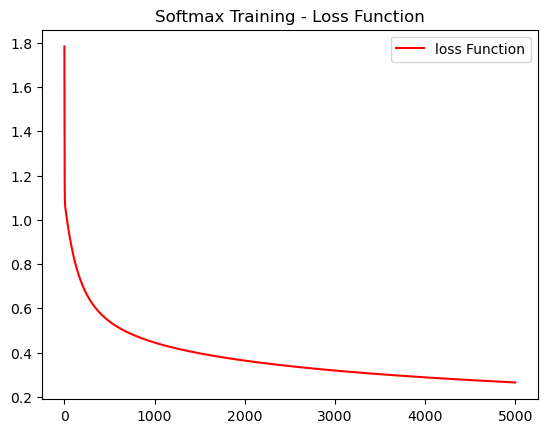

In [73]:
plt.plot(losses, label='loss Function', color='red')
plt.title('Softmax Training - Loss Function')
plt.legend()
plt.show()

In [74]:
# accuracy
y_pred = torch.argmax(model(X), dim=1)

acc = torch.sum(y_pred == y).item()/len(y)*100
print('accuracy score: {}%'.format(acc))

accuracy score: 100.0%
